In [165]:
# Code by Daniel Cho 003182370; no LLM: all hand-written. used docs. and stackexchange.  
import random 
import math
import numpy as np 
import matplotlib.pyplot as plt 
from numpy.linalg import inv 
from collections import deque

### Part 1: Data Generator


In [166]:
def generate_noisy_dataset(list_func, true_func, x_range, n_samples: int, epsilon=0.1):
    '''
    Function generate_noisy_dataset should generate the requested number of data records by sampling x
    uniformly at random from the given range. The corresponding y-value is computed as f(x) + noise, where
    noise is selected uniformly at random from range [-ε, ε]. You may return the generated data in any
    format you find convenient, e.g., one that matches the way scikit-learn prediction techniques expect
    tabular input consisting of input attributes and a label column.
    
    Here is an example: Assume you pass:
    - function list [f_1(x)=x2, f_2(x)=x3], 
    - true function f(x)=log(x), 
    - x-range[0.0,1.0], 
    - sample count 10, and 
    - noise level 0.1. 
    
    Then generate_noisy_dataset should generate 10 records,
    each by doing the following:
    - Randomly sample x between 0.0 and 1.0. Assume it sampled 0.5.
    - Compute the list of input attribute values as [0.5, 0.5*0.5, 0.5*0.5*0.5] = [0.5, 0.25, 0.125].
    - Compute output y as log(0.5) + random noise value drawn uniformly from range [-0.1, 0.1].
    Assume it ends up as y=-0.6.
    - Create data record [0.5, 0.25, 0.125; -0.6].
    '''
    record = []

    for i in range(n_samples):
        curr_iter = []
        x = round(random.uniform(x_range[0], x_range[1]), 3)
        curr_iter.append(x) 
        noise = round(random.uniform(-epsilon, epsilon), 3)  
        
        for func in list_func: 
            curr_iter.append(round(func(x), 3))
        curr_iter.append(round(noise + true_func(x), 3))
        record.append(curr_iter)
    return record 
        
        
    

In [167]:
# Example input 
list_func = [lambda x: x**2, lambda x: x**3] 
true_func = lambda x: math.log(x) 
x_range = [0.0,1.0] 
n_samples = 10 
epsilon = 0.1
res = generate_noisy_dataset(list_func, true_func, x_range, n_samples, epsilon)
res 

[[0.429, 0.184, 0.079, -0.824],
 [0.208, 0.043, 0.009, -1.65],
 [0.468, 0.219, 0.103, -0.715],
 [0.963, 0.927, 0.893, -0.007],
 [0.178, 0.032, 0.006, -1.632],
 [0.14, 0.02, 0.003, -1.895],
 [0.658, 0.433, 0.285, -0.358],
 [0.622, 0.387, 0.241, -0.398],
 [0.139, 0.019, 0.003, -1.883],
 [0.946, 0.895, 0.847, -0.093]]

#### Split into 80:20 for train/test split. 

In [168]:
def split_train_test(data): 
    split = int(len(data) * 0.8) 
    return data[:split], data[split:]
            

In [169]:
train, test = split_train_test(res)
print(f'Train: {train}')
print(f'Test: {test}')

Train: [[0.429, 0.184, 0.079, -0.824], [0.208, 0.043, 0.009, -1.65], [0.468, 0.219, 0.103, -0.715], [0.963, 0.927, 0.893, -0.007], [0.178, 0.032, 0.006, -1.632], [0.14, 0.02, 0.003, -1.895], [0.658, 0.433, 0.285, -0.358], [0.622, 0.387, 0.241, -0.398]]
Test: [[0.139, 0.019, 0.003, -1.883], [0.946, 0.895, 0.847, -0.093]]


### Part 2: Linear Regression

Training: Implement a function fit that takes in a training dataset generated by generate_noisy_dataset:

In [170]:
# 1. Convert the training data into the corresponding matrices and vectors (X, Y), making sure you
# include the column of 1s for the intercept.

In [171]:
trainXY = np.array(train)
testXY = np.array(test)
_, cols_tr = trainXY.shape
_, cols_ts = testXY.shape

In [172]:
train_X,train_y = trainXY[:,0:cols_tr-1], trainXY[:,cols_tr-1] 
print(train_X) 
print(train_y) 
train_X = np.column_stack([np.ones(len(train_X)), train_X]) 
print(train_X)

[[0.429 0.184 0.079]
 [0.208 0.043 0.009]
 [0.468 0.219 0.103]
 [0.963 0.927 0.893]
 [0.178 0.032 0.006]
 [0.14  0.02  0.003]
 [0.658 0.433 0.285]
 [0.622 0.387 0.241]]
[-0.824 -1.65  -0.715 -0.007 -1.632 -1.895 -0.358 -0.398]
[[1.    0.429 0.184 0.079]
 [1.    0.208 0.043 0.009]
 [1.    0.468 0.219 0.103]
 [1.    0.963 0.927 0.893]
 [1.    0.178 0.032 0.006]
 [1.    0.14  0.02  0.003]
 [1.    0.658 0.433 0.285]
 [1.    0.622 0.387 0.241]]


In [173]:
# 2. Use a linear-algebra library like numpy to compute 𝜷 = (𝑿^T𝑿)^-1𝑿^T𝒀.

In [174]:
def calc_weight(trainX, trainY):
    XTXinv = inv(np.dot(np.transpose(trainX), trainX)) # (X^T * X)^-1
    XTY = np.dot(np.transpose(trainX), trainY)      # X^T * Y 
    return np.dot(XTXinv, XTY) 

In [175]:
# 3. Output the weight vector.

In [176]:
betas = calc_weight(train_X, train_y)
betas

array([-2.60940913,  5.81087988, -4.38840084,  1.2016969 ])

In [177]:
# Prediction: Implement a function predict that takes in a weight vector and a test dataset. It should output
# all the corresponding predictions, each computed as 𝑦𝑝𝑟𝑒𝑑 = 𝜷 ∙ 𝑿. You will need to augment your test
# data to have the column of 1s like the training data; np.vstack([np.ones(x.shape[1]), x]) is one way to do this.

In [178]:
test_X, test_y = testXY[:,0:cols_ts-1], testXY[:,cols_ts-1]
print(test_X)
print(test_y)
test_X = np.column_stack([np.ones(len(test_X)),test_X]) 
print(test_X)

[[0.139 0.019 0.003]
 [0.946 0.895 0.847]]
[-1.883 -0.093]
[[1.    0.139 0.019 0.003]
 [1.    0.946 0.895 0.847]]


In [179]:
def pred(betas, test_X):
    return betas @ test_X.T
    

In [180]:
preds = pred(betas, test_X)
preds

array([-1.88147135, -0.02209824])

In [181]:
# Evaluation: Implement a function evaluate_model that, given predictions and true outputs, returns the root
# mean square error (RMSE). RMSE is computed by first dividing the total squared loss by the number of
# records, and then taking the square root of that.

In [182]:
def rmse(preds, gt):
    n = len(gt)
    return np.sqrt(np.mean((preds - gt)**2))

In [183]:
rmse(preds, test_y)

np.float64(0.050146765065889234)

### Part 3: Regression Tree

In [184]:

'''
For Part 3 I used AI, in writing out the fit(), predict(), and visualise() method. 

before we make the fit() method, it's prob best if we define some sort of Class to hold our tree--we could go with a Node class? 
is there anything particular about the class we should add outside of a typical Node? 
For a regression class, itll:
- be a leaf or 
- be a decision 
- we'll make it binary pathway 
'''

"\nfor this part i used AI. \n\nbefore we make the fit() method, it's prob best if we define some sort of Class to hold our tree--we could go with a Node class? \nis there anything particular about the class we should add outside of a typical Node? \nFor a regression class, itll:\n- be a leaf or \n- be a decision \n- we'll make it binary pathway \n"

In [185]:
class Node:
    def __init__(self):
        self.l = None
        self.r = None 
        self.pred = None 
        self.split_val = None 
        self.split = None
    def set_split(self, A, v):
        self.split = A
        self.split_val = v 

    def set_children(self, N1, N2): 
        self.l = N1
        self.r = N2 
 
    def set_prediction(self, D): 
        self.pred = D[:,-1].mean() 
        

In [186]:
def impurity(y): 
    y_bar = np.mean(y)
    return np.sum((y - y_bar)**2)

In [187]:
'''
Rows with column A ≤ v go left and the rest go right. Return both halves.
Check: on a 4-row toy array, print both halves and eyeball them.
'''
def split_data(D, A, v):
    mask = D[:, A] <= v 
    return D[mask], D[~mask] 

In [188]:
def split_score(D, A, v):
      left, right = split_data(D, A, v)
      if len(left) == 0 or len(right) == 0:
          return -np.inf  # nothing
      return impurity(D[:, -1]) - (impurity(left[:, -1]) + impurity(right[:, -1]))

In [201]:
# / Binary split procedure
# expand_node(node N, data D):
# for each attribute A in D:
#     for each distinct value v of D.A:
#         compute split_score(A, v)
#         (A_max, v_max) = split with greatest score
# N.set_split(A_max, v_max)
# (N_1, D_1), (N_2, D_2) = split_data(D, A_max, v_max)
# return (N_1, D_1), (N_2, D_2)
def expand_node(N, D): 
    best_score, A_max, v_max = -np.inf, None, None 
    for A in range(D.shape[1] - 1):
        for v in np.unique(D[:,A]): 
            score = split_score(D, A, v) 
            if score > best_score: 
                best_score = score 
                A_max = A
                v_max = v 
    N.set_split(A_max, v_max) 
    D1, D2 = split_data(D, A_max, v_max) 
    return (Node(), D1), (Node(), D2)
            

In [216]:
'''
Prompt: You are assigned to develop a machine learning regression tree without usage of external libraries. Follow according to 
the written pseudocode [pseudocide from slides pasted here. Ensure you develop the fit() method which trains the tree, predict() method which 
predicts on the generated dataset, and visualize() which should then visualize the splits the regression tree chose. 
You should also write out the code for helper methods such as split_data (which splits the decision to its two children) 
and split_score, according to the information/pseudocode found in the PDF slides of the material. The latter should use the gini impurity. 

'''
# fit(dataset, min_records): Build the tree on the data, e.g., using the approach shown in class. 
# The min_records parameter controls tree growth: Split a node only if it contains at least min_records training records, 
# otherwise make it a leaf.
class RegressionTree: 
    def fit(self, dataset, min_records):
        D = np.asarray(dataset, dtype=float) 
        self.root = Node() 
        q = deque([(self.root, D)])
        while q: 
            N, D = q.popleft() 
            if self.is_leaf(D, min_records): 
                N.set_prediction(D)
            else: 
                (N1, D1), (N2, D2) = expand_node(N, D)# .. expand_node
                N.set_children(N1, N2) 
                q.append([N1, D1]) 
                q.append([N2, D2]) 
        return self
        
    # predict(X): Make a prediction on input X.
    def predict(self, X): 
        X = np.asarray(X, dtype=float) 
        preds = np.empty(len(X)) 
        for i, row in enumerate(X): 
            N = self.root 
            while N.l is not None: 
                N = N.l if row[N.split] <= N.split_val else N.r 
            preds[i] = N.pred
        return preds
        
    # visualize(): In an x-y plot, show the tree split points and generate a line plot showing the
    # predictions of the tree for each part of the x-range.
    def visualize(self, list_func): 
        xs = np.linspace(0, 1, 1000) 
        X = np.column_stack([xs] + [[f(x) for x in xs] for f in list_func]) 
        preds = self.predict(X) 
        for x_split in xs[1:][(np.diff(preds) != 0)]: 
            plt.axvline(x_split, color='gray', lw=0.5, alpha=0.4)
        plt.plot(xs, preds, label='tree')

    def is_leaf(self, D, min_records): 
        return len(D) < min_records or np.all(D[:,:-1] == D[0,:-1])


In [217]:
rtree = RegressionTree() 
rtree.fit(train, 2) 

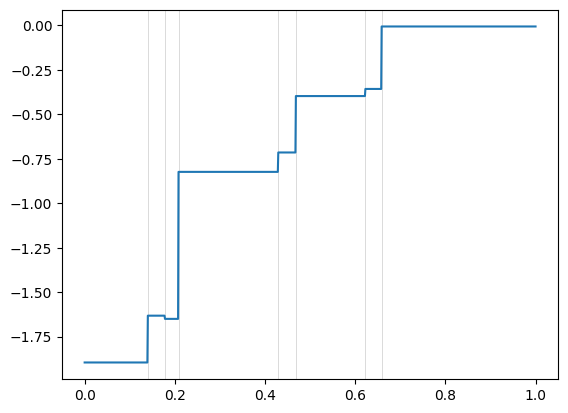

In [218]:
rtree.visualize(list_func)

### Report Q3 Plots 

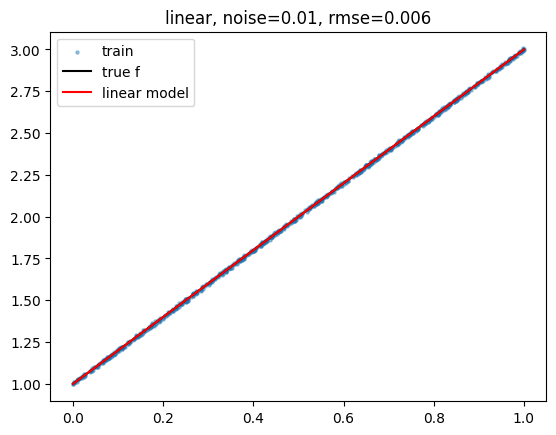

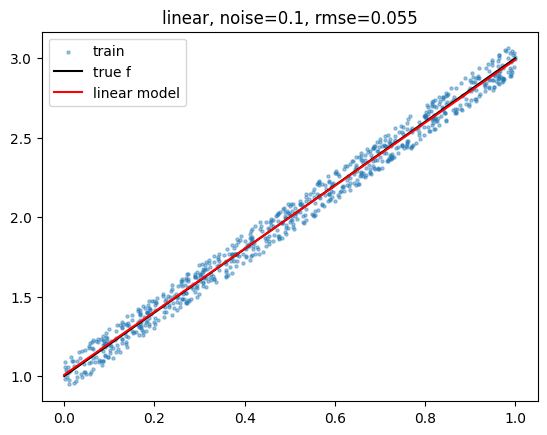

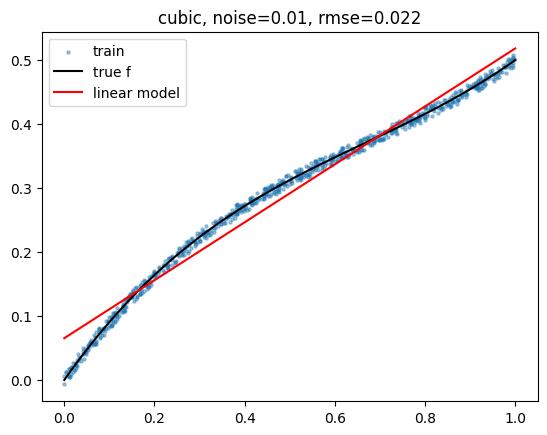

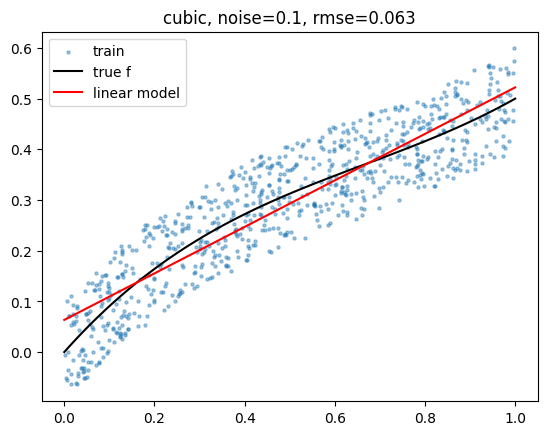

In [235]:
random.seed(42) 
true_funcs = {'linear': lambda x: 2*x + 1, 'cubic': lambda x: 0.5*x**3 - x**2 + x}
noise_levels = [0.01, 0.1] 
xs = np.linspace(0, 1, 100) 
datasets = {} 

for name, func in true_funcs.items(): 
    for eps in noise_levels: #list_func, true_func, x_range, n_samples: int, epsilon=0.1):
        data = generate_noisy_dataset([], func, [0.0, 1.0], 1000, eps) 
        train, test = split_train_test(data) 
        datasets[(name, eps)] = (train, test) 
        tr, ts = np.array(train), np.array(test) 

        X_tr = np.column_stack([np.ones(len(tr)), tr[:,:-1]]) 
        X_ts = np.column_stack([np.ones(len(ts)), ts[:,:-1]]) 
        betas = calc_weight(X_tr, tr[:,-1]) 
        test_rmse = rmse(pred(betas, X_ts), ts[:,-1]) 

        plt.figure() 
        plt.scatter(tr[:,0], tr[:,-1], s=5, alpha=0.4, label='train') 
        plt.plot(xs, func(xs), 'k', label='true f') 
        plt.plot(xs, betas[0]+ betas[1] * xs, 'r', label='linear model') 
        plt.title(f'{name}, noise={eps}, rmse={round(test_rmse, 3)}')
        plt.legend() 
        plt.show() 

### Report Q4 

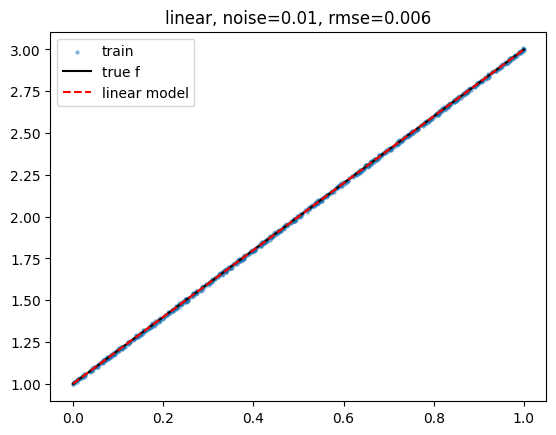

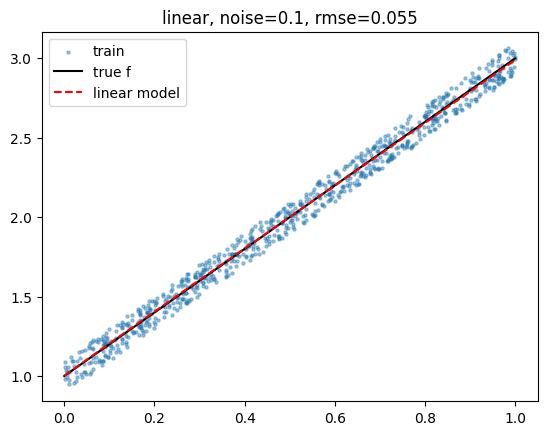

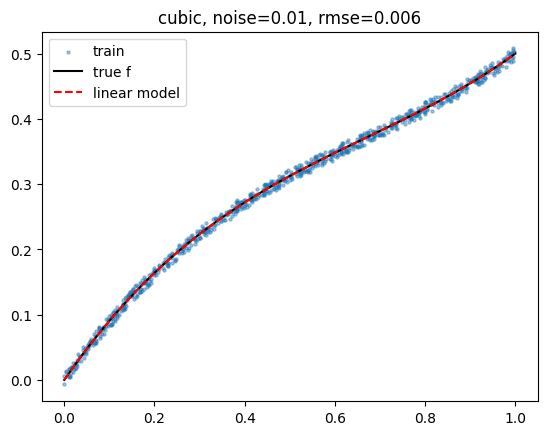

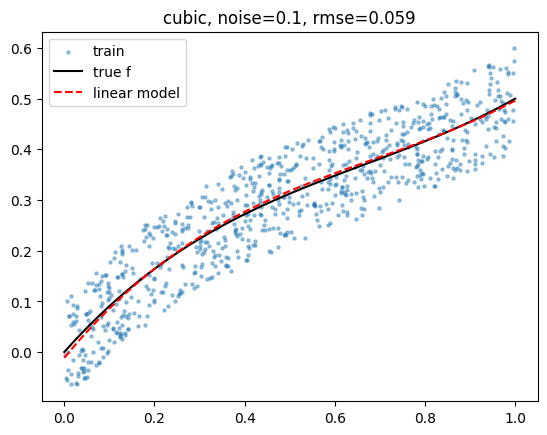

In [234]:
random.seed(42)
true_funcs = {'linear': lambda x: 2*x + 1, 'cubic': lambda x: 0.5*x**3 - x**2 + x}
noise_levels = [0.01, 0.1] 
xs = np.linspace(0, 1, 100) 
datasets = {} 

for name, func in true_funcs.items(): 
    for eps in noise_levels: #list_func, true_func, x_range, n_samples: int, epsilon=0.1):
        data = generate_noisy_dataset([], func, [0.0, 1.0], 1000, eps) 
        train, test = split_train_test(data) 
        datasets[(name, eps)] = (train, test) 
        tr, ts = np.array(train), np.array(test) 

        X_tr = np.column_stack([np.ones(len(tr)), tr[:,:-1], tr[:,:-1]**2, tr[:,:-1]**3]) 
        X_ts = np.column_stack([np.ones(len(ts)), ts[:,:-1], ts[:,:-1]**2, ts[:,:-1]**3]) 
        betas = calc_weight(X_tr, tr[:,-1]) 
        test_rmse = rmse(pred(betas, X_ts), ts[:,-1]) 

        plt.figure() 
        plt.scatter(tr[:,0], tr[:,-1], s=5, alpha=0.4, label='train') 
        plt.plot(xs, func(xs), 'k', label='true f') 
        # plt.plot(xs, betas[0]+ betas[1] * xs + betas[2]*xs**2, betas[3]*xs**3, 'r', label='linear model') 
        plt.plot(xs, betas[0] + betas[1]*xs + betas[2]*xs**2 + betas[3]*xs**3, 'r--', label='linear model')
        plt.title(f'{name}, noise={eps}, rmse={round(test_rmse, 3)}')
        plt.legend() 
        plt.savefig(f'../reports/hw2_report/q4_{name.lower()}_{str(eps).replace(".", "")}.png', dpi=150)
        plt.show() 

### Report Q5 

In [238]:
for (name, eps), (train, _) in datasets.items():
  tr = np.array(train)
  x = tr[:, 0]
  y10 = np.array([true_funcs[name](10)])

  # (x, y)
  b1 = calc_weight(np.column_stack([np.ones(len(x)), x]), tr[:, -1])
  err1 = rmse(pred(b1, np.array([[1, 10]])), y10)

  # (x, x^2, x^3, y)
  b3 = calc_weight(np.column_stack([np.ones(len(x)), x, x**2, x**3]), tr[:, -1])
  err3 = rmse(pred(b3, np.array([[1, 10, 100, 1000]])), y10)

  print(name, eps, round(err1, 3), round(err3, 3))

linear 0.01 0.002 9.066
linear 0.1 0.166 36.976
cubic 0.01 405.406 3.125
cubic 0.1 405.349 23.871


### Report Q6

In [242]:
for (name, eps), (train, test) in datasets.items():
  tr, ts = np.array(train), np.array(test)
  x_tr, x_ts = tr[:, 0], ts[:, 0]
  y10 = np.array([true_funcs[name](10)])

  # (x, y)
  b1 = calc_weight(np.column_stack([np.ones(len(x_tr)), x_tr]), tr[:, -1])
  test1 = rmse(pred(b1, np.column_stack([np.ones(len(x_ts)), x_ts])), ts[:, -1])
  ext1 = rmse(pred(b1, np.array([[1, 10]])), y10)

  # (x, x^2, x^3, y)
  b3 = calc_weight(np.column_stack([np.ones(len(x_tr)), x_tr, x_tr**2, x_tr**3]), tr[:, -1])
  test3 = rmse(pred(b3, np.column_stack([np.ones(len(x_ts)), x_ts, x_ts**2, x_ts**3])), ts[:, -1])
  ext3 = rmse(pred(b3, np.array([[1, 10, 100, 1000]])), y10)

  print(f'{name:6} eps={eps:<4}  (x,y): test={test1:.4f} x=10 err={ext1:.3f}   '
        f'(x,x2,x3,y): test={test3:.4f} x=10 err={ext3:.3f}, w: {b1}, w3: {b3}')

linear eps=0.01  (x,y): test=0.0057 x=10 err=0.002   (x,x2,x3,y): test=0.0058 x=10 err=9.066, w: [0.99993554 2.00024001], w3: [ 1.00094552  1.99095445  0.0190571  -0.01088173]
linear eps=0.1   (x,y): test=0.0545 x=10 err=0.166   (x,x2,x3,y): test=0.0546 x=10 err=36.976, w: [1.00811036 1.9825609 ], w3: [ 1.00201385  2.0319492  -0.09018408  0.04567322]
cubic  eps=0.01  (x,y): test=0.0220 x=10 err=405.406   (x,x2,x3,y): test=0.0059 x=10 err=3.125, w: [0.06535844 0.45285695], w3: [-5.00344270e-05  9.97975229e-01 -9.94179048e-01  4.96313254e-01]
cubic  eps=0.1   (x,y): test=0.0627 x=10 err=405.349   (x,x2,x3,y): test=0.0589 x=10 err=23.871, w: [0.06344254 0.45876732], w3: [-0.01134294  1.07537795 -1.1011446   0.5332435 ]


### Report Q7 

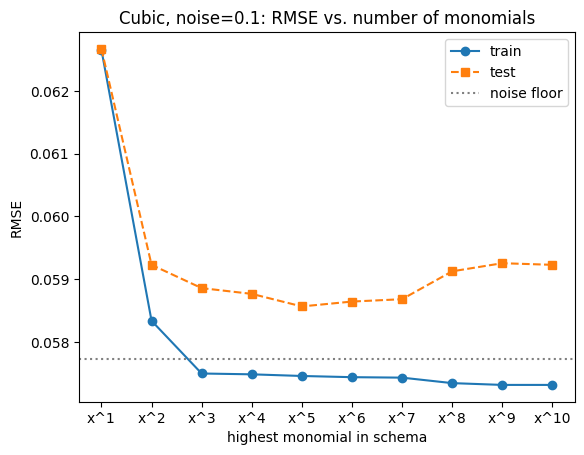

In [245]:
tr, ts = (np.array(d) for d in datasets[('cubic', 0.1)])
x_tr, y_tr = tr[:, 0], tr[:, -1]
x_ts, y_ts = ts[:, 0], ts[:, -1]

degrees = range(1, 11)   # (x,y), (x,x^2,y), ..., (x,...,x^10,y)
train_rmse, test_rmse = [], []
for d in degrees:
  X_tr = np.column_stack([np.ones(len(x_tr))] + [x_tr**k for k in range(1, d + 1)])
  X_ts = np.column_stack([np.ones(len(x_ts))] + [x_ts**k for k in range(1, d + 1)])
  b = calc_weight(X_tr, y_tr)
  train_rmse.append(rmse(pred(b, X_tr), y_tr))
  test_rmse.append(rmse(pred(b, X_ts), y_ts))

plt.figure()
plt.plot(degrees, train_rmse, 'o-', label='train')
plt.plot(degrees, test_rmse, 's--', label='test')
plt.axhline(0.1 / np.sqrt(3), color='gray', linestyle=':', label='noise floor')
plt.xticks(degrees, [f'x^{d}' for d in degrees])
plt.xlabel('highest monomial in schema')
plt.ylabel('RMSE')
plt.title('Cubic, noise=0.1: RMSE vs. number of monomials')
plt.legend()
plt.savefig('q7_plot.png')